# Deep E-prop: Credit Assignment Across Time and Depth

**Course:** NeuroAI & ML 4 Neuro — Sommersemester 2026  
**Authors:** Simon Peter · Yannick Säckl · Ruchit Kumar Patel  
**Repository:** github.com/simonpeter02/e-prop-in-deep-networks


---
## 1. Setup

Clone the repository, install dependencies, and auto-detect the compute device (GPU preferred).
All subsequent sections depend on this cell.

In [1]:
# Clone repo (skip if already present), then pull latest changes
import os

REPO_URL = "https://github.com/simonpeter02/e-prop-in-deep-networks.git"
REPO_DIR = "e-prop-in-deep-networks"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}

Cloning into 'e-prop-in-deep-networks'...
remote: Enumerating objects: 959, done.
remote: Counting objects: 100% (289/289), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 959 (delta 240), reused 170 (delta 127), pack-reused 670 (from 1)
Receiving objects: 100% (959/959), 2.50 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (774/774), done.
/content/e-prop-in-deep-networks


In [2]:
!pip install -q torch numpy matplotlib scipy

In [3]:
%matplotlib inline
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys, os

# Auto-detect best available device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Batch size: larger on GPU so each kernel has enough work to saturate the device
BATCH_GPU  = 128
BATCH_CPU  = 32
BATCH_DEFAULT = BATCH_GPU if DEVICE == "cuda" else BATCH_CPU
print(f"Default batch size: {BATCH_DEFAULT}")

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
Default batch size: 128


In [4]:
from tasks.store_and_recall  import generate_batch, task_accuracy
from tasks.cue_accumulation  import generate_batch as ca_batch, task_accuracy as ca_acc
from models.vanilla_rnn      import VanillaRNN
from models.leaky_rnn        import LeakyRNN          # promoted module; supports per-neuron alpha
from models.deep_rnn         import DeepRNN
from models.lif_rnn          import LIFNetwork, ALIFNetwork
from learning_rules.eprop         import compute_eprop_gradients, mse_error as sl_mse, xent_error
from learning_rules.eprop         import compute_eprop_leaky_gradients
from learning_rules.bptt          import compute_bptt_gradients, _mse_loss
from learning_rules.deep_eprop    import compute_deep_eprop_gradients, mse_error
from learning_rules.deep_rtrl     import compute_deep_rtrl_gradients
from learning_rules.interface     import apply_gradients
from learning_rules.bptt          import _xent_loss

SEED       = 42
N_PATTERNS = 4
torch.manual_seed(SEED)
np.random.seed(SEED)

from tasks.shd                 import (generate_batch as shd_batch,
                                       task_accuracy as shd_acc,
                                       T_SHD, N_IN_SHD, N_CLASSES as N_CLASSES_SHD)
from models.deep_alif              import DeepALIFNetwork
from learning_rules.deep_eprop_alif import compute_deep_eprop_alif_gradients

print('Imports OK')

Imports OK


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MASTER CONFIG — all tunable knobs in one place                         ║
# ║  Defaults are the MINIMUM that shows clean method separation on CPU.     ║
# ║  Values marked ↑ can be increased for publication-quality results.       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── Exp 1: single-layer e-prop (store-and-recall) ───────────────────────────
N_REC_SL    = 100
DELAY_SL    = 2
N_STEPS     = 1000      # ↑
LR          = 1e-3
EVAL_EVERY  = 50
delays_sl   = [1, 2, 3, 5, 10, 20, 50]
n_trials_sl = 30        # ↑

# ── Exp 2A: deep-RTRL verification ──────────────────────────────────────────
N_REC_RTRL  = 10
N_REPS      = 30        # ↑

# ── Exp 2B: 2-layer deep e-prop ─────────────────────────────────────────────
N_REC_2L    = 50
delays_2l_grid = [1, 2, 3, 5, 10, 20]
n_trials    = 30        # ↑
N_STEPS_2L  = 1000      # ↑
LR_2L       = 1e-3
EVAL_2L     = 50
delay_2l    = 2

# ── Exp 3: depth sweep ──────────────────────────────────────────────────────
# Cap at 3 for Colab CPU; change to [1,2,3,4,5] for pub-quality ↑
DEPTHS_SWEEP = [1, 2, 3]
DELAYS_SWEEP = [2, 5, 10]
N_REC_DS     = 50
N_TRIALS_DS  = 15       # ↑
N_STEPS_DS   = 600      # ↑
LR_DS        = 1e-3
EVAL_DS      = 30

# ── Exp 4: leaky RNN alpha sweep ─────────────────────────────────────────────
N_REC_LK     = 100
ALPHAS_LK    = [0.05, 0.1, 0.2, 0.5, 1.0]
DELAY_LK     = 5
N_TRIALS_LK  = 30       # ↑
ALPHA_LC     = 0.1      # alpha for learning curves
N_STEPS_LK   = 2000    # ↑
LR_LK        = 5e-3    # learning-curve LR; cosine sweep is LR-free
EVAL_LK      = 50

# ── Exp 5: cue accumulation + leaky RNN ─────────────────────────────────────
N_REC_CA     = 80       # ↑
ALPHA_CA     = 0.02     # slow leak: τ = 1/α = 50 steps; state retains 0.67 at D=20
N_CUES_CA    = 5        # odd → no ties
CUE_DUR_CA   = 1
ICI_CA       = 5        # inter-cue silence (steps)
DELAYS_CA    = [5, 10, 20, 30, 50]
N_TRIALS_CA  = 20       # ↑
N_STEPS_CA   = 800      # ↑ — see note in learning-curves cell
LR_CA        = 3e-3     # SGD; learning curves are indicative only — see cell note
EVAL_CA      = 40
DELAY_LC_CA  = 20       # delay for learning curves

# ── Batch sizes (set from device; see cell above) ────────────────────────────
BATCH_SL  = BATCH_DEFAULT
BATCH_2L  = BATCH_DEFAULT
BATCH_DS  = BATCH_DEFAULT
BATCH_LK  = BATCH_DEFAULT
BATCH_CA  = 128          # explicit: ≥128 reduces gradient noise on this task

# ── Input sizes ──────────────────────────────────────────────────────────────
n_in     = N_PATTERNS + 2   # store-and-recall: patterns + recall + bias
n_in_lk  = N_PATTERNS + 2   # leaky RNN (same task)
n_in_ca  = 5                 # cue-accum: left, right, recall, noise, bias

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Master config loaded.")

# ── Exp 5: Deep ALIF on Spiking Heidelberg Digits (SHD) ──────────────────────
N_REC_SHD      = 256        # neurons per layer
N_LAYERS_SHD   = 2          # number of recurrent layers
ALPHA_SHD      = 0.9        # membrane: fast trace carry ≈ 0.87, 1/e horizon ~8 steps
RHO_SHD        = 0.98       # adaptation: slow trace 1/e horizon ~50 steps ≈ T/2
# beta scales with (1-rho): a_ss = firing_rate/(1-rho) → at 5% firing, threshold shift ≈ v_th/2
BETA_SHD       = 0.02
V_TH_SHD       = 0.1        # spike threshold
GAMMA_SHD      = 0.3        # surrogate gradient peak magnitude
W_IN_SCALE_SHD = 5.0        # SHD is ~1% sparse; scale W_in so neurons fire at init
W_FF_SCALE_SHD = 8.0        # feedforward init drive also needs boosting
BATCH_SHD      = 64
N_STEPS_SHD    = 3000       # ↑ for production quality
LR_SHD         = 1e-3
GRAD_CLIP_SHD  = 1.0
EVAL_SHD       = 100
N_COSINE_SHD   = 50
T_SWEEP_SHD    = [10, 20, 50, 100]
HIDDEN_KEYS_SHD = (
    ['W_in']
    + [f'W_recs.{l}' for l in range(N_LAYERS_SHD)]
    + [f'W_ffs.{l}'  for l in range(N_LAYERS_SHD - 1)]
    + [f'b_recs.{l}' for l in range(N_LAYERS_SHD)]
)


Master config loaded.


In [6]:
def save_fig(fig, name, out_dir="results"):
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(f"{out_dir}/{name}.pdf", bbox_inches='tight')
    fig.savefig(f"{out_dir}/{name}.svg", bbox_inches='tight')
    print(f"Saved {out_dir}/{name}.pdf / .svg")

def bptt_grads_deep(model, inputs, targets, mask, loss_fn=None):
    if loss_fn is None:
        loss_fn = _mse_loss
    for p in model.parameters():
        if p.grad is not None: p.grad.zero_()
    outputs, _ = model(inputs)
    loss_fn(outputs, targets, mask).backward()
    return {k: p.grad.clone() for k, p in model.named_parameters() if p.grad is not None}

def cosine_keys(g1, g2, keys):
    sims = []
    for k in keys:
        if k not in g1 or k not in g2: continue
        v1, v2 = g1[k].flatten(), g2[k].flatten()
        if v1.norm() < 1e-12 or v2.norm() < 1e-12: continue
        sims.append(F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item())
    return float(np.mean(sims)) if sims else float('nan')

def apply_grads_deep(model, grads, lr):
    with torch.no_grad():
        for k, p in model.named_parameters():
            if k in grads: p.data -= lr * grads[k]

print("Helpers defined")

Helpers defined


In [7]:
# ── Clean slate: wipe results/ so each run holds ONLY the current outputs ─────
# (prevents an over-crowded folder of stale files from earlier naming schemes)
import shutil, os
shutil.rmtree("results", ignore_errors=True)
os.makedirs("results", exist_ok=True)
print("Cleared results/ — will be repopulated by this run.")

Cleared results/ — will be repopulated by this run.


---
## 5. Hierarchical Cue accumulation: Credit assignment across TIME and DEPTH, simultaneously

**Question.** Millidge (2025) shows deep e-prop *should* assign credit across both
depth and time. Does it, in practice, *at the same time*?

**Setup.** A 2-layer **leaky** `DeepRNN` with a FAST lower layer (transient feature
extractor, α=0.5) and a SLOW top layer (integrator, α=0.05), trained on a
hierarchical **classify-then-count** task (`tasks/hierarchical_cue.py`): each cue is
a mean-zero rising/falling temporal motif. The lower layer must learn the temporal
feature (**depth**); the top layer must accumulate the per-cue results across a
silent delay (**time**). Because the motifs are mean-zero, a frozen/random lower
layer (a reservoir) cannot fake the feature — so lower-layer credit genuinely matters.

**Two controls on the top-layer trace** `ε^z = (∂z/∂h)·ε^h + (∂z/∂z₍ₜ₋₁₎)·ε^z₍ₜ₋₁₎`:
- `ablate_spatial` (∂z/∂h = 0): removes the **depth** path → lower-layer grads → 0.
- `ablate_temporal` (∂z/∂z₍ₜ₋₁₎ = 0): removes the **cross-layer temporal** path.

**Predictions.** (5.1) full deep e-prop aligns with BPTT for *both* layers, while
each control breaks one dimension; most of the lower-layer credit flows through the
cross-layer temporal trace ε^z. (5.2) **BPTT ≥ full e-prop > both controls** in
learning. The full multi-seed study (incl. a delay sweep, E3) lives in
`experiments/deep_credit_time_depth.py`; the cells below run a compact version.

### 5.0 Trace anatomy: what exactly happens to ε^h and ε^z under each ablation

Deep e-prop (`learning_rules/deep_eprop.py`) maintains **two kinds of eligibility traces**
(written here for the 2-layer case used below, α = [0.5, 0.05]):

**Self-trace ε^h — within-layer, never ablated.** For every layer $l$:

$$\varepsilon^{h,l}_t \;=\; \underbrace{\alpha_l\,\psi^l_t \cdot (\text{presyn input})}_{\text{instantaneous seed}} \;+\; \underbrace{c^l_t \odot \varepsilon^{h,l}_{t-1}}_{\text{temporal carry}},
\qquad c^l_t = (1-\alpha_l) + \alpha_l\,\psi^l_t\,\mathrm{diag}(W^{l}_{\!rec})$$

It tracks how layer $l$'s *own* state depends on layer $l$'s *own* parameters through time.
**Neither ablation touches ε^h** — the `spatial_on` / `z_temporal_on` switches in the code
act only on the cross-layer update; the self-trace loop has no ablation guards at all.

**Cross-layer trace ε^z — the ablation target.** Tracks how the **top** state depends on
**lower-layer** parameters. The learning signal δ_t = err_t·W_out lands only on the top
layer, so ε^z is the *only* route by which lower-layer credit ever reaches δ:

$$\varepsilon^{z}_t \;=\; \underbrace{J^{ff}_t\,\varepsilon^{h,0}_t}_{\text{spatial seed } (\partial z/\partial h)} \;+\; \underbrace{c^{\,top}_t \odot \varepsilon^{z}_{t-1}}_{\text{temporal carry } (\partial z/\partial z_{t-1})},
\qquad J^{ff}_t = \alpha_{top}\,\psi^{top}_t \odot W_{ff}$$

Unrolled, ε^z is a sum over *entry times* $s$: lower-layer credit enters through the seed at
time $s$, then is held by the top layer's carry until $t$:

$$\varepsilon^{z}_t \;=\; \sum_{s\le t}\Big(\prod_{r=s+1}^{t} c^{\,top}_r\Big)\, J^{ff}_s\, \varepsilon^{h,0}_s$$

Each ablation deletes exactly one of the two terms:

| mode | ε^h (self) | ε^z update | ε^z value | lower-layer grads |
|---|---|---|---|---|
| `full` | intact | seed **+** carry | full sum over $s \le t$ | full deep e-prop |
| `ablate_spatial` | intact | carry only: $\varepsilon^z_t = c \odot \varepsilon^z_{t-1}$ | **exactly 0 for all $t$** (zero-initialised, never seeded) | **≡ 0** |
| `ablate_temporal` | intact | seed only: $\varepsilon^z_t = J^{ff}_t\,\varepsilon^{h,0}_t$ | only the $s{=}t$ term of the sum | non-zero, ~14× smaller |

**Consequences worth internalising:**

1. **Top-layer and readout gradients are identical in every mode.** `W_recs.1`, `W_ffs.0`,
   `biases.1` come from the intact self-trace ε^{h,1}; `W_out`, `b_out` need no trace at
   all. The ablations *only* change lower-layer credit (`W_in`, `W_recs.0`, `biases.0`) —
   which is why an ablated run still learns *something* (the top layer trains normally on
   whatever features the frozen-quality lower layer provides).
2. **`ablate_spatial` is multiplication by zero, forever.** ε^z starts at 0 and its only
   source term (the seed) is removed, so the update is c⊙0 = 0 at every step → lower-layer
   gradients are *exactly* zero, and layer 0 stays a random reservoir (the comparison run
   in 5.4.1 makes this explicit).
3. **`ablate_temporal` is memoryless at the hierarchy level — not at the lower layer.**
   ε^z is rebuilt from scratch each step, but its seed $J^{ff}_t\,\varepsilon^{h,0}_t$ still
   contains the lower layer's own temporal history (ε^{h,0} keeps its within-layer carry
   c⁰ ≈ 0.5). What is lost is the **top layer holding lower-layer credit across the delay**:
   with α_top = 0.05 the top carry is c^top ≈ 0.95, so the $s<t$ terms dominate the full
   sum — hence the ~14× collapse in lower-layer gradient *magnitude* while the *direction*
   barely moves (cosine ≈ 0.98; see the 5.2 optimiser note).
4. Legacy `d_zero` (not used in this section) is harsher: it drops the temporal carry of
   **both** ε^h and ε^z, keeping only instantaneous same-timestep credit everywhere.

So: "ε₀ = 0" is only the *initial condition*. Every step re-seeds the traces with a
non-zero instantaneous term — unless a mode removes that seed, which only
`ablate_spatial` does, and only for ε^z. That is why ablated runs are not all-zero:
the zeros are confined to exactly the lower-layer gradients of `ablate_spatial`.


In [8]:
# ── Experiment 5 setup ──────────────────────────────────────────────────────
from models.deep_rnn          import DeepRNN
from learning_rules.deep_eprop import compute_deep_eprop_gradients, xent_error
from learning_rules.bptt       import compute_bptt_gradients, _xent_loss
from learning_rules.interface  import apply_gradients
from tasks.hierarchical_cue    import generate_batch as hcue, task_accuracy as hacc
from utils                     import cosine_sim_grads, flat_grads
import time, json, warnings

E5_NREC   = 32
E5_ALPHA  = [0.5, 0.05]          # fast lower extractor + slow top integrator
E5_NCUES  = 3
E5_TASK   = dict(cue_duration=3, inter_cue_interval=2, amp=2.0, feature_noise=0.15)
E5_LOWER  = ["W_in", "W_recs.0", "biases.0"]      # lower-layer (layer-0) params
E5_UPPER  = ["W_recs.1", "W_ffs.0", "biases.1"]   # top-layer (layer-1) params
E5_DELAYS     = [6, 12, 20]
E5_DELAY_MAIN = 12               # learning-curve delay; also the summary-bar delay
E5_STEPS      = 2000             # ↑ (legacy fixed budget; superseded by E5_MAX_STEPS)
E5_SEEDS      = 8                # learning-curve seeds
E5_COS_SEEDS  = 16               # gradient-cosine seeds  ↑
E5_BATCH      = globals().get("BATCH_DEFAULT", 48)
E5_LR         = 1e-3             # Adam learning rate (5.2 trains with Adam — see below)
E5_EVAL       = 100
E5_EVAL_N     = 512              # samples per eval batch (×reps) — de-noises curves
E5_EVAL_REPS  = 4

# ── Optimiser + convergence-stopping config (used in 5.2) ────────────────────
# 5.2 trains with Adam (per-parameter step normalisation), NOT plain SGD. The credit
# ablations distort gradient *magnitude* far more than *direction* (ablate_temporal
# collapses the lower-layer gradient ~14x but keeps cosine≈0.98; ablate_spatial
# zeroes it). Under shared-LR SGD that magnitude deficit masquerades as a lower final
# accuracy; Adam removes magnitude as a variable per synapse (and is the optimiser
# used in the e-prop literature and our SHD scripts). With magnitude neutralised all
# rules converge to the SAME accuracy on this task — the credit-quality difference is
# in convergence SPEED, which the learning curves show. Each method trains to its own
# convergence (patience, with a min-steps floor so a slow starter isn't cut off early).
E5_GRAD_CLIP = 1.0               # global-norm gradient clip (matches SHD scripts)
E5_MIN_STEPS = 1500              # don't allow early stop before this (slow-starter guard)
E5_MAX_STEPS = 4000              # convergence cap / runaway guard
E5_PATIENCE  = 8                 # evals (×E5_EVAL steps) of no EMA improvement before stopping
E5_TOL       = 5e-3              # min EMA improvement that counts as progress
E5_TAIL_K    = 5                 # evals tail-averaged for the converged-accuracy readout

def e5_batch(B, delay, seed):
    inp, tgt, msk = hcue(B, n_cues=E5_NCUES, delay=delay, seed=seed, **E5_TASK)
    return inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)

def e5_stats(res):
    # mean and standard error over seeds (rows); all-nan cols (e.g. the unrun tail of
    # an early-stopped seed) return nan/0 without noisy warnings.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(res, axis=0); sd = np.nanstd(res, axis=0, ddof=1)
    n = np.sum(~np.isnan(res), axis=0)
    sem = np.where(n > 1, sd / np.sqrt(np.maximum(n, 1)), 0.0)
    return mean, sem

print("Exp 5 ready. alpha", E5_ALPHA, "| seeds: cosine", E5_COS_SEEDS, "learning", E5_SEEDS)


Exp 5 ready. alpha [0.5, 0.05] | seeds: cosine 16 learning 8


5.1 gradient credit (16 seeds) ...
  D=  6: full low=0.793±0.015 top=0.959 | temporal low=0.696±0.035 | spatial low=0 | xshare=0.92
  D= 12: full low=0.760±0.019 top=0.943 | temporal low=0.713±0.027 | spatial low=0 | xshare=0.93
  D= 20: full low=0.726±0.017 top=0.923 | temporal low=0.694±0.019 | spatial low=0 | xshare=0.94
Saved results/exp5_gradient_credit.pdf / .svg


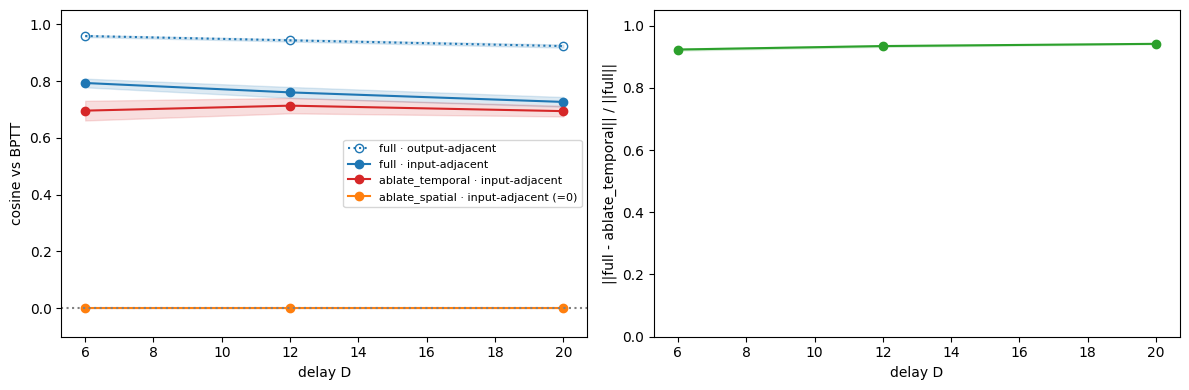

Saved results/exp5_credit_summary.pdf / .svg


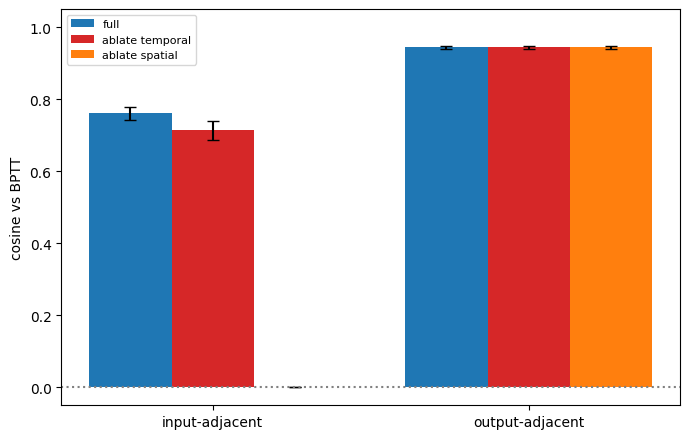

Saved exp5 gradient credit + summary.


In [9]:
# ── 5.1  Gradient credit: per-layer cosine vs BPTT + cross-temporal share ────
print(f"5.1 gradient credit ({E5_COS_SEEDS} seeds) ...")
E5_CK = ["full_low", "full_up", "temp_low", "temp_up", "spat_low", "spat_up", "xshare"]
e5_mean, e5_sem = {}, {}
for d in E5_DELAYS:
    rows = []
    for s in range(E5_COS_SEEDS):
        torch.manual_seed(1000 + s)
        m = DeepRNN(5, E5_NREC, 2, n_layers=2, alpha=E5_ALPHA).to(DEVICE)
        inp, tgt, msk = e5_batch(E5_BATCH, d, 5000 + s)
        gb = compute_bptt_gradients(m, inp, tgt, msk, _xent_loss)
        gf = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="full")
        gt = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="ablate_temporal")
        gs = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="ablate_spatial")
        a, b = flat_grads(gf, E5_LOWER), flat_grads(gt, E5_LOWER)
        rows.append([cosine_sim_grads(gf, gb, E5_LOWER), cosine_sim_grads(gf, gb, E5_UPPER),
                     cosine_sim_grads(gt, gb, E5_LOWER), cosine_sim_grads(gt, gb, E5_UPPER),
                     cosine_sim_grads(gs, gb, E5_LOWER), cosine_sim_grads(gs, gb, E5_UPPER),
                     ((a - b).norm() / (a.norm() + 1e-12)).item()])
    mu, er = e5_stats(np.array(rows, dtype=float))
    e5_mean[d] = dict(zip(E5_CK, mu)); e5_sem[d] = dict(zip(E5_CK, er))
    print(f"  D={d:3d}: full low={e5_mean[d]['full_low']:.3f}±{e5_sem[d]['full_low']:.3f} "
          f"top={e5_mean[d]['full_up']:.3f} | temporal low={e5_mean[d]['temp_low']:.3f}±{e5_sem[d]['temp_low']:.3f}"
          f" | spatial low=0 | xshare={e5_mean[d]['xshare']:.2f}")

def _ser(stat, k):
    return np.nan_to_num(np.array([stat[d][k] for d in E5_DELAYS]))

# Figure 1 — per-layer cosine vs delay, with stderr bands
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for k, c, ls, lab, mfc in [("full_up", "C0", ":", "full · output-adjacent", "none"), ("full_low", "C0", "-", "full · input-adjacent", "C0"),
                      ("temp_low", "C3", "-", "ablate_temporal · input-adjacent", "C3"),
                      ("spat_low", "C1", "-", "ablate_spatial · input-adjacent (=0)", "C1")]:
    mu, er = _ser(e5_mean, k), _ser(e5_sem, k)
    ax.plot(E5_DELAYS, mu, marker="o", color=c, ls=ls, label=lab, markerfacecolor=mfc)
    ax.fill_between(E5_DELAYS, mu - er, mu + er, color=c, alpha=0.15)
ax.axhline(0, color="gray", ls=":"); ax.set_xlabel("delay D"); ax.set_ylabel("cosine vs BPTT")
ax.set_ylim(-0.1, 1.05); ax.legend(fontsize=8)
ax = axes[1]
mu, er = _ser(e5_mean, "xshare"), _ser(e5_sem, "xshare")
ax.plot(E5_DELAYS, mu, "o-", color="C2"); ax.fill_between(E5_DELAYS, mu - er, mu + er, color="C2", alpha=0.15)
ax.set_xlabel("delay D"); ax.set_ylabel("||full - ablate_temporal|| / ||full||"); ax.set_ylim(0, 1.05)
fig.tight_layout(); save_fig(fig, "exp5_gradient_credit"); plt.show()

# Figure 2 — summary bars at the main delay (reuses the same cosines)
db = E5_DELAY_MAIN if E5_DELAY_MAIN in e5_mean else E5_DELAYS[len(E5_DELAYS) // 2]
kf = {("full", "low"): "full_low", ("full", "top"): "full_up",
      ("ablate_temporal", "low"): "temp_low", ("ablate_temporal", "top"): "temp_up",
      ("ablate_spatial", "low"): "spat_low", ("ablate_spatial", "top"): "spat_up"}
fig, ax = plt.subplots(figsize=(7, 4.5)); x = np.arange(2); w = 0.26
for i, (meth, c) in enumerate([("full", "C0"), ("ablate_temporal", "C3"), ("ablate_spatial", "C1")]):
    mus = [np.nan_to_num(e5_mean[db][kf[(meth, l)]]) for l in ("low", "top")]
    ers = [np.nan_to_num(e5_sem[db][kf[(meth, l)]]) for l in ("low", "top")]
    ax.bar(x + (i - 1) * w, mus, w, yerr=ers, capsize=4, color=c, label=meth.replace("ablate_", "ablate "))
ax.set_xticks(x); ax.set_xticklabels(["input-adjacent", "output-adjacent"]); ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color="gray", ls=":"); ax.set_ylabel("cosine vs BPTT")
ax.legend(fontsize=8); fig.tight_layout(); save_fig(fig, "exp5_credit_summary"); plt.show()

with open("results/exp5_gradient_credit.json", "w") as _f:
    json.dump({"delays": E5_DELAYS, "mean": e5_mean, "sem": e5_sem, "n": E5_COS_SEEDS}, _f)
print("Saved exp5 gradient credit + summary.")

5.2 learning curves (D=12, 8 seeds, Adam lr=1e-03) ...
  BPTT                   conv-acc=1.000  steps-to-converge≈2387  tail-slope/100=+0.0000  [650s]
  deep e-prop (full)     conv-acc=0.999  steps-to-converge≈2537  tail-slope/100=+0.0001  [832s]
  ablate temporal        conv-acc=0.996  steps-to-converge≈2712  tail-slope/100=-0.0011  [640s]
  ablate spatial         conv-acc=0.989  steps-to-converge≈2862  tail-slope/100=-0.0081  [978s]
Convergence check: conv-acc should be ~equal across methods and |tail-slope/100|≈0 (raise E5_MAX_STEPS if any method still slopes up).
Saved results/exp5_learning_curves.pdf / .svg


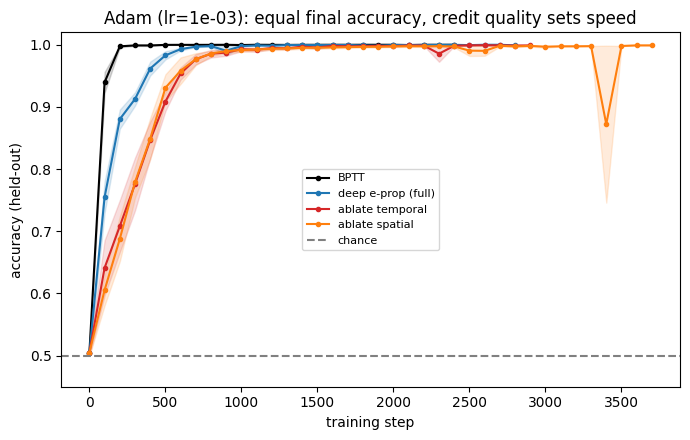

Saved Adam exp5 learning curves (+ per-seed curves for 5.3).


In [10]:
# ── 5.2  Adam learning curves: credit quality sets convergence SPEED ──────────
# Trained with Adam, which normalises the per-synapse step size and so removes the
# ablations' gradient-MAGNITUDE deficit, leaving only gradient direction/structure.
# Under fair optimisation every rule converges to the SAME final accuracy on this
# task, so the credit-assignment difference shows up as convergence SPEED (full >
# ablate_temporal > ablate_spatial), which these curves display. Each method trains
# to its own convergence (patience + min-steps floor). There is no plateau-height
# claim here; the SPEED differences are significance-tested in 5.3.
print(f"5.2 learning curves (D={E5_DELAY_MAIN}, {E5_SEEDS} seeds, Adam lr={E5_LR:.0e}) ...")

def e5_eval(m, delay):
    accs = []
    for e in range(E5_EVAL_REPS):
        ie, te, me = e5_batch(E5_EVAL_N, delay, 90000 + e)
        with torch.no_grad():
            o, _ = m(ie)
        accs.append(hacc(o, te, me))
    return float(np.mean(accs))

e5_methods = [("bptt", "BPTT"), ("full", "deep e-prop (full)"),
              ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]

def e5_grads(method, m, inp, tgt, msk):
    if method == "bptt":
        return compute_bptt_gradients(m, inp, tgt, msk, _xent_loss)
    return compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode=method)

# ── Patience-based training with Adam: stop once each method has converged ────
def e5_train(method, seed):
    torch.manual_seed(seed)
    m = DeepRNN(5, E5_NREC, 2, n_layers=2, alpha=E5_ALPHA).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=E5_LR)
    accs, ema, best, since, st = [], None, -1.0, 0, 0
    while True:
        if st % E5_EVAL == 0:
            a = e5_eval(m, E5_DELAY_MAIN); accs.append(a)
            ema = a if ema is None else 0.3 * a + 0.7 * ema
            if ema > best + E5_TOL:
                best, since = ema, 0
            else:
                since += 1
            if (since >= E5_PATIENCE and st >= E5_MIN_STEPS) or st >= E5_MAX_STEPS:
                break
        inp, tgt, msk = e5_batch(E5_BATCH, E5_DELAY_MAIN, 10_000 + seed * 1_000_000 + st)
        g = e5_grads(method, m, inp, tgt, msk)
        opt.zero_grad()
        for pname, p in m.named_parameters():            # custom grads -> Adam step
            p.grad = g.get(pname, torch.zeros_like(p))
        torch.nn.utils.clip_grad_norm_(m.parameters(), E5_GRAD_CLIP)
        opt.step()
        st += 1
    return accs            # ragged: length = #evals until this run converges

def e5_tail_slope(r):      # per-100-step slope over the converged tail (≈0 if flat)
    k = min(E5_TAIL_K, len(r))
    return float(np.polyfit(np.arange(k), np.asarray(r[-k:]), 1)[0]) if k >= 2 else 0.0

e5_curves, e5_convacc, e5_stops, e5_rows = {}, {}, {}, {}
for meth, lab in e5_methods:
    t0 = time.time()
    rows = [e5_train(meth, s) for s in range(E5_SEEDS)]   # ragged per-seed eval curves
    e5_rows[meth] = rows
    L = max(len(r) for r in rows)
    M = np.full((len(rows), L), np.nan)            # nan-pad ragged runs to a common grid
    for i, r in enumerate(rows):
        M[i, :len(r)] = r
    mu, sem = e5_stats(M)                           # nan-aware mean / SEM over seeds
    e5_curves[meth]  = (mu, sem)
    e5_convacc[meth] = np.array([float(np.mean(r[-E5_TAIL_K:])) for r in rows])  # converged acc
    e5_stops[meth]   = [(len(r) - 1) * E5_EVAL for r in rows]
    slope = float(np.mean([e5_tail_slope(r) for r in rows]))
    print(f"  {lab:22s} conv-acc={e5_convacc[meth].mean():.3f}  "
          f"steps-to-converge≈{int(np.mean(e5_stops[meth]))}  tail-slope/100={slope:+.4f}  "
          f"[{time.time()-t0:.0f}s]")
print("Convergence check: conv-acc should be ~equal across methods and "
      "|tail-slope/100|≈0 (raise E5_MAX_STEPS if any method still slopes up).")

# ── Figure: Adam curves — equal final accuracy, different convergence speed ───
col = {"bptt": "k", "full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}
fig, ax = plt.subplots(figsize=(7, 4.5))
for meth, lab in e5_methods:
    mu, er = e5_curves[meth]
    x = np.arange(len(mu)) * E5_EVAL
    ax.plot(x, mu, "-o", ms=3, color=col[meth], label=lab)
    ax.fill_between(x, mu - er, mu + er, color=col[meth], alpha=0.15)
ax.axhline(0.5, color="gray", ls="--", label="chance")
ax.set_xlabel("training step"); ax.set_ylabel("accuracy (held-out)"); ax.set_ylim(0.45, 1.02)
ax.set_title(f"Adam (lr={E5_LR:.0e}): equal final accuracy, credit quality sets speed")
ax.legend(fontsize=8)
fig.tight_layout(); save_fig(fig, "exp5_learning_curves"); plt.show()

# Snapshot the prior shared-LR SGD curves once (before overwrite) for before/after contrast.
import os, shutil
_old, _snap = "results/exp5_learning_curves.json", "results/exp5_learning_curves_sgd.json"
if os.path.exists(_old) and not os.path.exists(_snap):
    shutil.copy(_old, _snap); print(f"Snapshotted prior SGD curves -> {_snap}")

with open(_old, "w") as _f:
    json.dump({"eval_every": E5_EVAL, "optimizer": "adam", "lr": float(E5_LR),
               "curves":      {m: [c[0].tolist(), c[1].tolist()] for m, c in e5_curves.items()},
               "conv_acc":    {m: e5_convacc[m].tolist()          for m, _ in e5_methods},
               "stop_steps":  {m: e5_stops[m]                     for m, _ in e5_methods},
               "per_seed":    {m: e5_rows[m]                      for m, _ in e5_methods}}, _f)
print("Saved Adam exp5 learning curves (+ per-seed curves for 5.3).")



Steps to reach acc≥0.90  (paired sign-flip perm, Holm over 3):
    BPTT                   mean=    95 steps
    deep e-prop (full)     mean=   255 steps
    ablate temporal        mean=   473 steps
    ablate spatial         mean=   459 steps
    comparison                  Δsteps     dz   perm p     Holm
    full vs ablate_temporal       -217  -1.71   0.0078   0.0234  *
    full vs ablate_spatial        -203  -1.37   0.0234   0.0469  *
    temporal vs spatial            +14  +0.18   0.6328   0.6328  ns

Steps to reach acc≥0.80  (paired sign-flip perm, Holm over 3):
    BPTT                   mean=    69 steps
    deep e-prop (full)     mean=   131 steps
    ablate temporal        mean=   260 steps
    ablate spatial         mean=   328 steps
    comparison                  Δsteps     dz   perm p     Holm
    full vs ablate_temporal       -129  -0.96   0.0469   0.0625  ns
    full vs ablate_spatial        -196  -1.96   0.0078   0.0234  *
    temporal vs spatial            -67  -1.13  

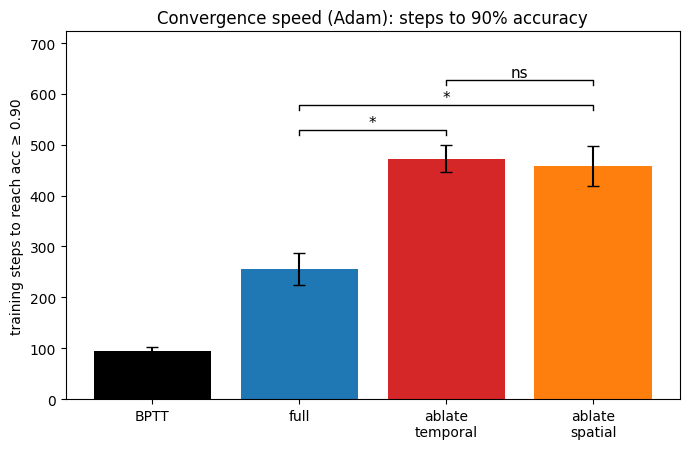


Cluster-permutation significant intervals (window 0–2200 steps, pointwise α=0.05, FWER-controlled over time):
    full vs ablate_temporal    [200–700] steps (p=0.008)
    full vs ablate_spatial     [100–400] steps (p=0.008), [1300–1600] steps (p=0.047)
    temporal vs spatial        none
Saved results/exp5_speed_intervals.pdf / .svg


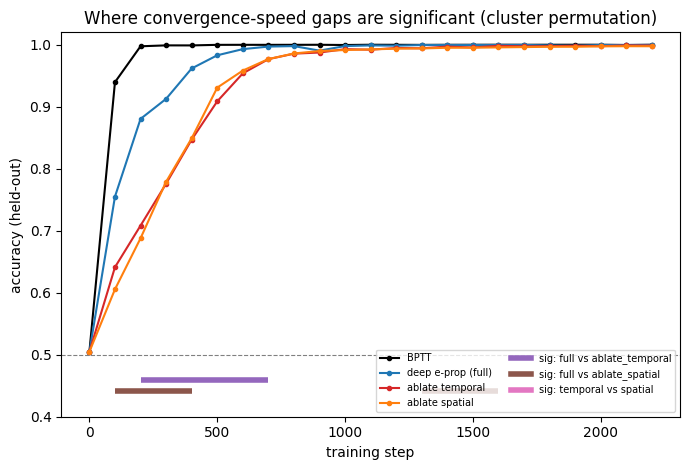

Saved exp5_speed_threshold + exp5_speed_intervals.


In [11]:
# ── 5.3  Speed significance: are the convergence-rate gaps real? ──────────────
# Adam makes every rule converge to the same accuracy, so the credit-assignment
# signal is in SPEED. Two independent, paired (per-seed) tests on the 5.2 curves —
# no extra training. Comparisons: full vs ablate_temporal, full vs ablate_spatial,
# ablate_temporal vs ablate_spatial (Holm-corrected over the 3).
from experiments.stats import paired_report, holm, cluster_perm_test

# Re-run-safe: rebuild per-seed curves from disk if 5.2 isn't in memory.
try:
    e5_rows; e5_methods; col; E5_EVAL
except NameError:
    with open("results/exp5_learning_curves.json") as _f:
        _d = json.load(_f)
    e5_methods = [("bptt", "BPTT"), ("full", "deep e-prop (full)"),
                  ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]
    e5_rows = {m: _d["per_seed"][m] for m, _ in e5_methods}
    E5_EVAL = _d["eval_every"]
    col = {"bptt": "k", "full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}

E5_SPEED_COMPS = [("full", "ablate_temporal", "full vs ablate_temporal", "C4"),
                  ("full", "ablate_spatial",  "full vs ablate_spatial",  "C5"),
                  ("ablate_temporal", "ablate_spatial", "temporal vs spatial", "C6")]
_lab = {m: lab for m, lab in e5_methods}

def _stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

# ── (A) Steps-to-threshold ────────────────────────────────────────────────────
def steps_to_threshold(r, theta, eval_every=E5_EVAL):
    """Interpolated training step at which curve r first reaches theta (NaN if never)."""
    r = np.asarray(r, float)
    above = np.where(r >= theta)[0]
    if len(above) == 0:
        return float("nan")
    i = int(above[0])
    if i == 0:
        return 0.0
    y0, y1 = r[i - 1], r[i]
    frac = 0.0 if y1 == y0 else (theta - y0) / (y1 - y0)
    return (i - 1 + min(max(frac, 0.0), 1.0)) * eval_every

def speed_threshold_report(theta):
    s2t = {m: np.array([steps_to_threshold(r, theta) for r in e5_rows[m]])
           for m, _ in e5_methods}
    cens = {m: int(np.isnan(s2t[m]).sum()) for m, _ in e5_methods}
    reports = [(lab, a, b, paired_report(s2t[a], s2t[b])) for a, b, lab, _ in E5_SPEED_COMPS]
    padj = holm([r["p_perm"] for *_, r in reports])
    print(f"\nSteps to reach acc≥{theta:.2f}  (paired sign-flip perm, Holm over {len(reports)}):")
    for m, _ in e5_methods:
        c = f"  ({cens[m]} censored)" if cens[m] else ""
        print(f"    {_lab[m]:22s} mean={np.nanmean(s2t[m]):6.0f} steps{c}")
    print(f"    {'comparison':26s} {'Δsteps':>7} {'dz':>6} {'perm p':>8} {'Holm':>8}")
    for (lab, a, b, r), pa in zip(reports, padj):
        print(f"    {lab:26s} {r['mean_diff']:+7.0f} {r['cohen_dz']:+6.2f} "
              f"{r['p_perm']:8.4f} {pa:8.4f}  {_stars(pa)}")
    return s2t, reports, padj

E5_THETA = 0.9
s2t, e5_spd_reports, e5_spd_padj = speed_threshold_report(E5_THETA)
speed_threshold_report(0.8)        # robustness check at a lower threshold

# Figure A (independent): mean steps-to-threshold per method ± SEM, with brackets.
order = ["bptt", "full", "ablate_temporal", "ablate_spatial"]
short = {"bptt": "BPTT", "full": "full", "ablate_temporal": "ablate\ntemporal",
         "ablate_spatial": "ablate\nspatial"}
means = {m: float(np.nanmean(s2t[m])) for m in order}
sems  = {m: float(np.nanstd(s2t[m], ddof=1) / np.sqrt(np.sum(~np.isnan(s2t[m])))) for m in order}
figA, axA = plt.subplots(figsize=(7, 4.6)); xs = np.arange(len(order))
axA.bar(xs, [means[m] for m in order], yerr=[sems[m] for m in order], capsize=4,
        color=[col[m] for m in order])
axA.set_xticks(xs); axA.set_xticklabels([short[m] for m in order])
axA.set_ylabel(f"training steps to reach acc ≥ {E5_THETA:.2f}")
axA.set_title(f"Convergence speed (Adam): steps to {E5_THETA:.0%} accuracy")
y0 = max(means[m] + sems[m] for m in order)
for k, (a, b, lab, _) in enumerate(E5_SPEED_COMPS):
    xa, xb = order.index(a), order.index(b); y = y0 * (1.06 + 0.10 * k)
    axA.plot([xa, xa, xb, xb], [y - y0 * 0.02, y, y, y - y0 * 0.02], color="k", lw=1)
    axA.text((xa + xb) / 2, y, _stars(e5_spd_padj[k]), ha="center", va="bottom", fontsize=11)
axA.set_ylim(0, y0 * 1.45)
figA.tight_layout(); save_fig(figA, "exp5_speed_threshold"); plt.show()

# ── (B) Cluster-permutation: where over training are the gaps significant? ─────
# Common rectangular window: up to the earliest stop across all methods/seeds.
n_common = min(len(r) for m, _ in e5_methods for r in e5_rows[m])
A = {m: np.array([r[:n_common] for r in e5_rows[m]]) for m, _ in e5_methods}
t_axis = np.arange(n_common) * E5_EVAL

print(f"\nCluster-permutation significant intervals (window 0–{t_axis[-1]} steps, "
      f"pointwise α=0.05, FWER-controlled over time):")
e5_sig_intervals = {}
for a, b, lab, _c in E5_SPEED_COMPS:
    cl = cluster_perm_test(A[a] - A[b])
    sig = [c for c in cl if c["p_cluster"] < 0.05]
    e5_sig_intervals[(a, b)] = sig
    spans = ", ".join(f"[{t_axis[c['t0']]}–{t_axis[c['t1']]}] steps (p={c['p_cluster']:.3f})"
                      for c in sig) or "none"
    print(f"    {lab:26s} {spans}")

# Figure B (independent): mean curves over the window + per-comparison sig bars.
figB, axB = plt.subplots(figsize=(7, 4.8))
for meth, lab in e5_methods:
    axB.plot(t_axis, A[meth].mean(0), "-o", ms=3, color=col[meth], label=lab)
axB.axhline(0.5, color="gray", ls="--", lw=0.8)
axB.set_xlabel("training step"); axB.set_ylabel("accuracy (held-out)")
axB.set_ylim(0.40, 1.02)
axB.set_title("Where convergence-speed gaps are significant (cluster permutation)")
ybar = 0.46
for k, (a, b, lab, cc) in enumerate(E5_SPEED_COMPS):
    y = ybar - 0.018 * k
    for c in e5_sig_intervals[(a, b)]:
        axB.plot([t_axis[c["t0"]], t_axis[c["t1"]]], [y, y], color=cc, lw=4, solid_capstyle="butt")
    axB.plot([], [], color=cc, lw=4, label=f"sig: {lab}")
axB.legend(fontsize=7, ncol=2, loc="lower right")
figB.tight_layout(); save_fig(figB, "exp5_speed_intervals"); plt.show()
print("Saved exp5_speed_threshold + exp5_speed_intervals.")


---
### Mechanism: reservoir control + linear probes

§5.1–5.3 establish *that* deep e-prop assigns credit across depth and time. This
section asks *why the lower layer must learn* — turning two assertions from the §5
intro ("a frozen/random lower layer cannot fake the feature"; "the top layer
accumulates the per-cue result across the delay") into **measured** results.

**Three measurements** (2-layer net, α=[0.5, 0.05], task identical to §5.1/5.2):

1. **Reservoir control** (`5.4.1`) — freeze the lower layer at its *random* init and
   train only the top layer + readout with **exact BPTT, to convergence** (its best
   shot). Compare converged accuracy to a **full** net (lower trainable). Unlike §5.2,
   a final-*accuracy* gap is meaningful here: a frozen lower layer is an *architectural*
   restriction, not a credit-rule ablation, so it *can* cap the plateau. Reported with a
   paired sign-flip permutation test (full vs reservoir).
2. **Lower-layer probe** (`5.4.2`) — linearly decode each cue's side (rising/falling)
   from the lower-layer state, swept over steps *after* the cue (a persistence curve),
   for the **trained** vs the **random** lower layer. Tests whether the per-cue feature
   is present and held — and whether a random reservoir can fake it.
3. **Top-layer probe** (`5.4.2`) — linearly decode the running count from the top-layer
   state *across the silent delay*, trained vs random. Tests time-integration.

**Honest framing.** These can *refute* the intro's claims, not just confirm them — e.g.
a random leaky layer may well encode the per-cue feature transiently (a reservoir
property), in which case the decisive credit evidence is the reservoir *task* result +
the top probe, and the lower probe localizes *where* the bottleneck is (feature presence
vs integration/formatting). Labels for the probes are the true per-cue sides, recovered
from the input by a matched filter (the probe itself decodes only from hidden states).

**Reusability / compute.** Self-contained: the setup cell re-imports everything and
(re)defines all helpers, so after a runtime disconnect re-run only the clone / `pip` /
device cells at the very top, then this section. Every result is checkpointed to
`results/exp5_4_*.json` and the run cells **resume** (skip seeds already on disk);
trained *full* models are cached to `results/exp5_4_models/` and **shared** between
5.4.1 and 5.4.2; the figure cell rebuilds plots **from disk**. Cost ≈ `E54_RES_SEEDS`
reservoir + `E54_RES_SEEDS` full trainings to convergence (similar per-run cost to one
§5.2 method) → **GPU recommended**; lower `E54_RES_SEEDS` to trade statistical power for
speed. Note: do **not** run the "Clean slate" wipe cell between sessions if you want to
reuse these checkpoints.


In [12]:
# ── 5.4 setup — self-contained: re-imports + config + all helpers ────────────
# Depends only on the clone / pip / device cells at the very top of the notebook.
import os, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.deep_rnn        import DeepRNN
from learning_rules.bptt    import compute_bptt_gradients, _xent_loss
from tasks.hierarchical_cue import generate_batch as hcue, task_accuracy as hacc
from experiments.stats      import paired_report
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"], check=True)
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split

DEVICE = globals().get("DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu")
os.makedirs("results", exist_ok=True); os.makedirs("figures", exist_ok=True)

def e54_save(fig, name, out="results"):
    """Save pdf + svg + png (png so figures are viewable in Colab without conversion)."""
    os.makedirs(out, exist_ok=True)
    for ext in ("pdf", "svg", "png"):
        fig.savefig(f"{out}/{name}.{ext}", bbox_inches="tight", dpi=150 if ext == "png" else None)
    print(f"Saved {out}/{name}.(pdf|svg|png)")

# ── config (task identical to §5.1 / 5.2) ────────────────────────────────────
E54_NREC, E54_ALPHA, E54_NCUES, E54_DELAY = 32, [0.5, 0.05], 3, 12
E54_TASK = dict(cue_duration=3, inter_cue_interval=2, amp=2.0, feature_noise=0.15)
E54_BATCH    = globals().get("BATCH_DEFAULT", 48)
E54_LR, E54_GRAD_CLIP        = 1e-3, 1.0       # Adam (matches §5.2)
E54_MIN_STEPS, E54_MAX_STEPS = 1500, 4000      # give the reservoir a fair, converged shot
E54_PATIENCE, E54_TOL        = 8, 5e-3
E54_EVAL, E54_EVAL_N, E54_EVAL_REPS, E54_TAIL_K = 100, 512, 4, 5
E54_RES_SEEDS, E54_PROBE_SEEDS, E54_PROBE_N = 8, 5, 1500
E54_LOWER_OFFSETS = [0, 1, 2]                  # steps after a cue ends (into the silence)

LOWER_PARAMS = {"W_in", "W_recs.0", "biases.0"}    # layer-0 params (frozen in the reservoir)
CUE_DUR, ICI = E54_TASK["cue_duration"], E54_TASK["inter_cue_interval"]
CUE_STRIDE   = CUE_DUR + ICI
CUE_WINDOW   = E54_NCUES * CUE_STRIDE
T_RECALL     = CUE_WINDOW + E54_DELAY
BASE         = torch.linspace(-E54_TASK["amp"], E54_TASK["amp"], CUE_DUR)  # rising ramp

RES_PATH, PROBE_PATH = "results/exp5_4_reservoir.json", "results/exp5_4_probes.json"
MODELS_DIR = "results/exp5_4_models"

def e54_batch(B, seed, delay=E54_DELAY):
    return hcue(B, n_cues=E54_NCUES, delay=delay, seed=seed, device=DEVICE, **E54_TASK)

def e54_eval(m, delay=E54_DELAY):
    accs = []
    for e in range(E54_EVAL_REPS):
        ie, te, me = e54_batch(E54_EVAL_N, 90000 + e, delay)
        with torch.no_grad():
            o, _ = m(ie)
        accs.append(hacc(o, te, me))
    return float(np.mean(accs))

def e54_new_model(seed):
    torch.manual_seed(seed)
    return DeepRNN(5, E54_NREC, 2, n_layers=2, alpha=E54_ALPHA).to(DEVICE)

def e54_train(seed, freeze_lower=False):
    """Train to convergence with Adam on EXACT BPTT grads. freeze_lower => reservoir:
    layer-0 params held at their random init; only the top layer + readout learn."""
    m = e54_new_model(seed)
    if freeze_lower:
        for name, p in m.named_parameters():
            if name in LOWER_PARAMS:
                p.requires_grad_(False)
    train_ps = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.Adam(train_ps, lr=E54_LR)
    accs, ema, best, since, st = [], None, -1.0, 0, 0
    while True:
        if st % E54_EVAL == 0:
            a = e54_eval(m); accs.append(a)
            ema = a if ema is None else 0.3 * a + 0.7 * ema
            if ema > best + E54_TOL: best, since = ema, 0
            else:                    since += 1
            if (since >= E54_PATIENCE and st >= E54_MIN_STEPS) or st >= E54_MAX_STEPS:
                break
        inp, tgt, msk = e54_batch(E54_BATCH, 700_000 + seed * 1_000_000 + st)
        g = compute_bptt_gradients(m, inp, tgt, msk, _xent_loss)
        opt.zero_grad()
        for name, p in m.named_parameters():
            if p.requires_grad:
                p.grad = g.get(name, torch.zeros_like(p))
        torch.nn.utils.clip_grad_norm_(train_ps, E54_GRAD_CLIP)
        opt.step(); st += 1
    return m, accs, float(np.mean(accs[-E54_TAIL_K:]))

def e54_get_full_model(seed):
    """Trained full net (lower trainable), cached to disk + shared by 5.4.1 / 5.4.2.
    Returns (model, info) where info is (curve, conv_acc) on a fresh train, else None."""
    path = f"{MODELS_DIR}/full_seed{seed}.pt"
    if os.path.exists(path):
        m = e54_new_model(seed)
        m.load_state_dict(torch.load(path, map_location=DEVICE)); m.eval()
        return m, None
    m, accs, conv = e54_train(seed, freeze_lower=False)
    os.makedirs(MODELS_DIR, exist_ok=True)
    torch.save(m.state_dict(), path)
    return m, (accs, conv)

# ── probes ────────────────────────────────────────────────────────────────────
def e54_recover_sides(inp):
    """Ground-truth per-cue side from the input via a matched filter on the feature
    channel (sign of <cue, rising-ramp>). Used only to LABEL the probes — the probes
    themselves decode from hidden states, never the input."""
    b = BASE.to(inp.device); B = inp.shape[1]
    sides = torch.zeros(B, E54_NCUES, dtype=torch.long)
    for c in range(E54_NCUES):
        t0 = c * CUE_STRIDE
        sides[:, c] = ((b[:, None] * inp[t0:t0 + CUE_DUR, :, 0]).sum(0) < 0).long()
    return sides

def e54_decode(X, y, seed=0):
    """Linear-probe held-out accuracy + majority-class baseline (30% test split)."""
    strat = y if len(np.unique(y)) > 1 else None
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=strat)
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
    _, cnt = np.unique(ytr, return_counts=True)
    return float(clf.score(Xte, yte)), float(cnt.max() / cnt.sum())

def e54_lower_probe(model, seed=12345):
    """Decode per-cue side (rising/falling) from the LOWER layer, swept over offsets
    after the cue ends -> a persistence curve."""
    inp, _, _ = e54_batch(E54_PROBE_N, seed)
    with torch.no_grad():
        _, allh = model(inp)
    sides = e54_recover_sides(inp); curve = []
    for off in E54_LOWER_OFFSETS:
        feats, labs = [], []
        for c in range(E54_NCUES):
            t = c * CUE_STRIDE + CUE_DUR - 1 + off
            feats.append(allh[t + 1][0].cpu().numpy()); labs.append(sides[:, c].cpu().numpy())
        acc, ch = e54_decode(np.concatenate(feats, 0), np.concatenate(labs, 0))
        curve.append([off, acc, ch])
    return curve

def e54_top_probe(model, seed=23456):
    """Decode the running count (# falling cues) from the TOP layer across the delay."""
    inp, tgt, _ = e54_batch(E54_PROBE_N, seed)
    with torch.no_grad():
        _, allh = model(inp)
    sides = e54_recover_sides(inp)
    y = sides.sum(1).cpu().numpy()                       # 0..n_cues  (count class)
    lab = tgt[T_RECALL].argmax(-1).cpu().numpy()
    agree = float(np.mean((y > E54_NCUES / 2).astype(int) == lab))   # sanity vs task label
    curve = []
    for t in range(CUE_WINDOW - 1, T_RECALL + 1, 2):
        acc, ch = e54_decode(allh[t + 1][1].cpu().numpy(), y)
        curve.append([t, acc, ch])
    return curve, agree

print(f"5.4 ready | device {DEVICE} | batch {E54_BATCH} | res-seeds {E54_RES_SEEDS} "
      f"probe-seeds {E54_PROBE_SEEDS} | T_recall {T_RECALL}")


5.4 ready | device cuda | batch 128 | res-seeds 8 probe-seeds 5 | T_recall 27


In [13]:
# ── 5.4.1  Reservoir control: frozen random lower layer vs full (BPTT, converged) ─
# RESUMABLE: skips seeds already in results/exp5_4_reservoir.json. Full models are
# cached to results/exp5_4_models/ and reused by 5.4.2.
assert "e54_train" in globals(), "Run the 5.4 setup cell first."

res = json.load(open(RES_PATH)) if os.path.exists(RES_PATH) else {"full": {}, "reservoir": {}}
res.setdefault("full", {}); res.setdefault("reservoir", {})
print(f"5.4.1 reservoir control ({E54_RES_SEEDS} seeds, Adam+BPTT to convergence) ...")
for s in range(E54_RES_SEEDS):
    ks = str(s)
    if ks not in res["full"]:                                  # full reference (cached model)
        t0 = time.time(); m, info = e54_get_full_model(s)
        accs, conv = info if info is not None else ([e54_eval(m)], e54_eval(m))
        res["full"][ks] = dict(seed=s, conv_acc=conv, curve=accs)
        json.dump(res, open(RES_PATH, "w"), indent=1)
        print(f"  full      seed {s}  conv={conv:.3f}  [{time.time()-t0:.0f}s]")
    else:
        print(f"  [skip] full      seed {s}  conv={res['full'][ks]['conv_acc']:.3f}")
    if ks not in res["reservoir"]:                             # reservoir (frozen lower)
        t0 = time.time(); _, accs, conv = e54_train(s, freeze_lower=True)
        res["reservoir"][ks] = dict(seed=s, conv_acc=conv, curve=accs)
        json.dump(res, open(RES_PATH, "w"), indent=1)
        print(f"  reservoir seed {s}  conv={conv:.3f}  [{time.time()-t0:.0f}s]")
    else:
        print(f"  [skip] reservoir seed {s}  conv={res['reservoir'][ks]['conv_acc']:.3f}")

full = np.array([res["full"][str(s)]["conv_acc"]      for s in range(E54_RES_SEEDS)])
rsv  = np.array([res["reservoir"][str(s)]["conv_acc"] for s in range(E54_RES_SEEDS)])
rep  = paired_report(full, rsv); res["paired_full_vs_reservoir"] = rep
json.dump(res, open(RES_PATH, "w"), indent=1)
print(f"\n  full      conv-acc = {full.mean():.3f} ± {full.std(ddof=1)/np.sqrt(len(full)):.3f}")
print(f"  reservoir conv-acc = {rsv.mean():.3f} ± {rsv.std(ddof=1)/np.sqrt(len(rsv)):.3f}")
print(f"  full − reservoir   = {rep['mean_diff']:+.3f}  (dz={rep['cohen_dz']:+.2f}, "
      f"perm p={rep['p_perm']:.4f})")
print("Done 5.4.1 — saved", RES_PATH)


5.4.1 reservoir control (8 seeds, Adam+BPTT to convergence) ...
  full      seed 0  conv=1.000  [80s]
  reservoir seed 0  conv=1.000  [72s]
  full      seed 1  conv=1.000  [80s]
  reservoir seed 1  conv=1.000  [62s]
  full      seed 2  conv=1.000  [81s]
  reservoir seed 2  conv=1.000  [64s]
  full      seed 3  conv=1.000  [80s]
  reservoir seed 3  conv=1.000  [70s]
  full      seed 4  conv=1.000  [80s]
  reservoir seed 4  conv=1.000  [65s]
  full      seed 5  conv=1.000  [78s]
  reservoir seed 5  conv=1.000  [78s]
  full      seed 6  conv=1.000  [85s]
  reservoir seed 6  conv=1.000  [60s]
  full      seed 7  conv=1.000  [81s]
  reservoir seed 7  conv=1.000  [60s]

  full      conv-acc = 1.000 ± 0.000
  reservoir conv-acc = 1.000 ± 0.000
  full − reservoir   = +0.000  (dz=+0.13, perm p=1.0000)
Done 5.4.1 — saved results/exp5_4_reservoir.json


In [14]:
# ── 5.4.2  Linear probes: lower-layer feature + top-layer count (trained vs random) ─
# RESUMABLE: skips seeds already in results/exp5_4_probes.json. Reuses the cached full
# models from 5.4.1 (trains one only if a seed's model is missing).
assert "e54_lower_probe" in globals(), "Run the 5.4 setup cell first."

pr = json.load(open(PROBE_PATH)) if os.path.exists(PROBE_PATH) else {}
print(f"5.4.2 linear probes ({E54_PROBE_SEEDS} seeds) ...")
for s in range(E54_PROBE_SEEDS):
    ks = str(s)
    if ks in pr:
        print(f"  [skip] probe seed {s}"); continue
    t0 = time.time()
    trained, _ = e54_get_full_model(s)        # cached if 5.4.1 already ran
    rand = e54_new_model(s)                    # untrained init (same seed as `trained`)
    lt, lr = e54_lower_probe(trained), e54_lower_probe(rand)
    tt, ag = e54_top_probe(trained); tr, _ = e54_top_probe(rand)
    pr[ks] = dict(lower_trained=lt, lower_random=lr, top_trained=tt, top_random=tr,
                  label_agree=ag)
    json.dump(pr, open(PROBE_PATH, "w"), indent=1)
    print(f"  seed {s}: lower side-decode  trained {lt[0][1]:.2f}->{lt[-1][1]:.2f}  "
          f"random {lr[0][1]:.2f}->{lr[-1][1]:.2f}  (offset {E54_LOWER_OFFSETS[0]}->{E54_LOWER_OFFSETS[-1]})")
    print(f"          top count-decode @recall  trained {tt[-1][1]:.2f}  random {tr[-1][1]:.2f}  "
          f"(chance {tt[-1][2]:.2f}) | label-agree {ag:.2f}  [{time.time()-t0:.0f}s]")
print("Done 5.4.2 — saved", PROBE_PATH)


5.4.2 linear probes (5 seeds) ...
  seed 0: lower side-decode  trained 1.00->1.00  random 1.00->1.00  (offset 0->2)
          top count-decode @recall  trained 0.98  random 0.47  (chance 0.37) | label-agree 1.00  [0s]
  seed 1: lower side-decode  trained 1.00->1.00  random 1.00->1.00  (offset 0->2)
          top count-decode @recall  trained 0.96  random 0.54  (chance 0.37) | label-agree 1.00  [1s]
  seed 2: lower side-decode  trained 1.00->1.00  random 1.00->1.00  (offset 0->2)
          top count-decode @recall  trained 0.94  random 0.50  (chance 0.37) | label-agree 1.00  [2s]
  seed 3: lower side-decode  trained 1.00->1.00  random 1.00->1.00  (offset 0->2)
          top count-decode @recall  trained 0.95  random 0.54  (chance 0.37) | label-agree 1.00  [1s]
  seed 4: lower side-decode  trained 1.00->1.00  random 1.00->1.00  (offset 0->2)
          top count-decode @recall  trained 0.78  random 0.52  (chance 0.37) | label-agree 1.00  [1s]
Done 5.4.2 — saved results/exp5_4_probes.json


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved results/exp5_4_reservoir.(pdf|svg|png)


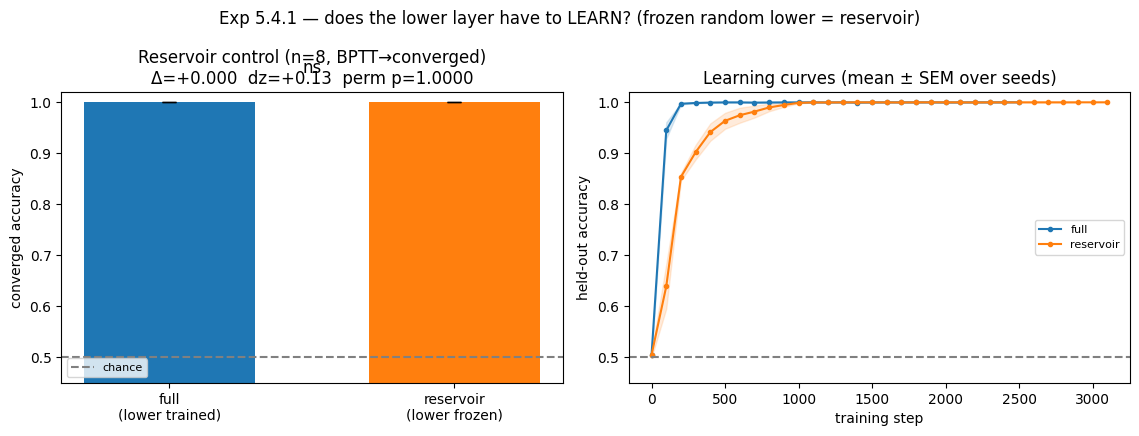

Saved results/exp5_4_lower_probe.(pdf|svg|png)


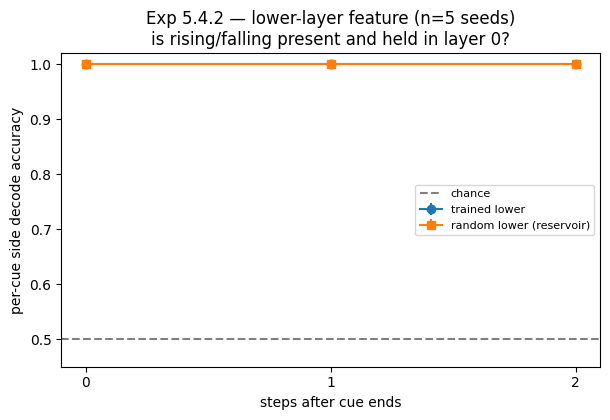

Saved results/exp5_4_top_probe.(pdf|svg|png)


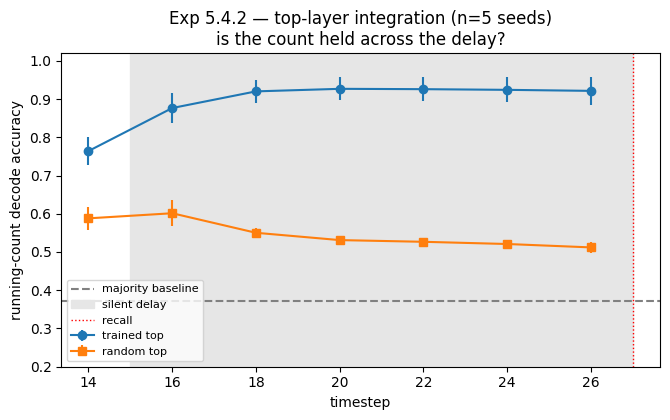

Saved exp5_4_reservoir / exp5_4_lower_probe / exp5_4_top_probe.


In [15]:
# ── 5.4.3  Figures — rebuilt from results/exp5_4_*.json on disk ───────────────
# Needs the 5.4 setup cell (constants + e54_save). Survives a runtime disconnect: it
# reads only the JSON files, with no in-memory dependency on the run cells.
res = json.load(open(RES_PATH)); pr = json.load(open(PROBE_PATH))
def _sem(a):
    a = np.asarray(a, float)
    return float(a.std(ddof=1) / np.sqrt(len(a))) if len(a) > 1 else 0.0
def _stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

# ── Figure A — reservoir vs full: converged accuracy (bar+test) + learning curves ─
seeds_r = sorted(int(k) for k in res["full"])
full = np.array([res["full"][str(s)]["conv_acc"]      for s in seeds_r])
rsv  = np.array([res["reservoir"][str(s)]["conv_acc"] for s in seeds_r])
rep  = res.get("paired_full_vs_reservoir", {})
pval = rep.get("p_perm", float("nan"))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a0.bar([0, 1], [full.mean(), rsv.mean()], yerr=[_sem(full), _sem(rsv)], capsize=5,
       color=["C0", "C1"], width=0.6)
a0.axhline(0.5, color="gray", ls="--", label="chance")
a0.set_xticks([0, 1]); a0.set_xticklabels(["full\n(lower trained)", "reservoir\n(lower frozen)"])
a0.set_ylabel("converged accuracy"); a0.set_ylim(0.45, 1.02)
yb = max(full.mean() + _sem(full), rsv.mean() + _sem(rsv)) + 0.05
a0.plot([0, 0, 1, 1], [yb - 0.012, yb, yb, yb - 0.012], color="k", lw=1)
a0.text(0.5, yb, _stars(pval) if pval == pval else "", ha="center", va="bottom", fontsize=12)
a0.set_title(f"Reservoir control (n={len(seeds_r)}, BPTT→converged)\n"
             f"Δ={rep.get('mean_diff', float('nan')):+.3f}  dz={rep.get('cohen_dz', float('nan')):+.2f}  "
             f"perm p={pval:.4f}")
a0.legend(loc="lower left", fontsize=8)
for cond, c in [("full", "C0"), ("reservoir", "C1")]:
    rows = [res[cond][str(s)]["curve"] for s in seeds_r]
    L = max(len(r) for r in rows); M = np.full((len(rows), L), np.nan)
    for i, r in enumerate(rows):
        M[i, :len(r)] = r
    x = np.arange(L) * E54_EVAL
    mu = np.nanmean(M, 0)
    sm = np.nanstd(M, 0, ddof=1) / np.sqrt(np.maximum(np.sum(~np.isnan(M), 0), 1))
    a1.plot(x, mu, "-o", ms=3, color=c, label=cond)
    a1.fill_between(x, mu - sm, mu + sm, color=c, alpha=0.15)
a1.axhline(0.5, color="gray", ls="--"); a1.set_xlabel("training step")
a1.set_ylabel("held-out accuracy"); a1.set_ylim(0.45, 1.02); a1.legend(fontsize=8)
a1.set_title("Learning curves (mean ± SEM over seeds)")
fig.suptitle("Exp 5.4.1 — does the lower layer have to LEARN? (frozen random lower = reservoir)")
fig.tight_layout(); e54_save(fig, "exp5_4_reservoir"); plt.show()

# ── Figure B — lower-layer feature: side-decode persistence (trained vs random) ──
sl   = sorted(int(k) for k in pr)
offs = [o for o, _, _ in pr[str(sl[0])]["lower_trained"]]
LT = np.array([[a for _, a, _ in pr[str(s)]["lower_trained"]] for s in sl])
LR = np.array([[a for _, a, _ in pr[str(s)]["lower_random"]]  for s in sl])
fig, ax = plt.subplots(figsize=(6.2, 4.3))
ax.errorbar(offs, LT.mean(0), yerr=LT.std(0, ddof=1) / np.sqrt(len(sl)), marker="o",
            color="C0", label="trained lower")
ax.errorbar(offs, LR.mean(0), yerr=LR.std(0, ddof=1) / np.sqrt(len(sl)), marker="s",
            color="C1", label="random lower (reservoir)")
ax.axhline(0.5, color="gray", ls="--", label="chance")
ax.set_xticks(offs); ax.set_xlabel("steps after cue ends")
ax.set_ylabel("per-cue side decode accuracy"); ax.set_ylim(0.45, 1.02); ax.legend(fontsize=8)
ax.set_title(f"Exp 5.4.2 — lower-layer feature (n={len(sl)} seeds)\n"
             "is rising/falling present and held in layer 0?")
fig.tight_layout(); e54_save(fig, "exp5_4_lower_probe"); plt.show()

# ── Figure C — top-layer integration: count-decode across the delay ──────────────
tps = [t for t, _, _ in pr[str(sl[0])]["top_trained"]]
TT = np.array([[a for _, a, _ in pr[str(s)]["top_trained"]] for s in sl])
TR = np.array([[a for _, a, _ in pr[str(s)]["top_random"]]  for s in sl])
ch = float(np.mean([[c for _, _, c in pr[str(s)]["top_trained"]] for s in sl]))
fig, ax = plt.subplots(figsize=(6.8, 4.3))
ax.errorbar(tps, TT.mean(0), yerr=TT.std(0, ddof=1) / np.sqrt(len(sl)), marker="o",
            color="C0", label="trained top")
ax.errorbar(tps, TR.mean(0), yerr=TR.std(0, ddof=1) / np.sqrt(len(sl)), marker="s",
            color="C1", label="random top")
ax.axhline(ch, color="gray", ls="--", label="majority baseline")
ax.axvspan(CUE_WINDOW, T_RECALL, color="0.9", label="silent delay")
ax.axvline(T_RECALL, color="r", ls=":", lw=1, label="recall")
ax.set_xlabel("timestep"); ax.set_ylabel("running-count decode accuracy")
ax.set_ylim(0.2, 1.02); ax.legend(fontsize=8)
ax.set_title(f"Exp 5.4.2 — top-layer integration (n={len(sl)} seeds)\n"
             "is the count held across the delay?")
fig.tight_layout(); e54_save(fig, "exp5_4_top_probe"); plt.show()

print("Saved exp5_4_reservoir / exp5_4_lower_probe / exp5_4_top_probe.")


---
### 5.5 Do the gradients actually change? Per-layer readout + ablation probes

Three quick, self-contained checks that make the ablation mechanism *visible* rather than
asserted. They reuse the 5.4 setup cell (constants + helpers), so run that first.

- **5.5.1 gradient sanity** — compute the deep-e-prop gradient of *one* model on *one*
  batch under every rule and compare. Confirms the mechanism directly: `ablate_spatial`
  zeroes the lower-layer gradient *exactly*; `ablate_temporal` keeps its direction
  (cos≈0.97 vs full) but collapses its magnitude ~14×; both leave the **top-layer**
  gradient bit-identical (the controls touch only the cross-layer trace ε^z); `d_zero`
  changes *both* layers (it also truncates the self-trace ε^h).
- **5.5.2 per-layer readout** — a minimal linear decode of the *task label* from each
  layer's state at recall. One number per layer: how task-relevant is layer 0 vs layer 1.
- **5.5.3 ablation probes** — the piece 5.4.2 was missing: train a model *under each rule*
  (deep-e-prop grads, Adam) and probe its lower/top layers. This reads off **which regime
  each ablation lands in** — a genuinely-trained feature extractor vs a frozen-style
  reservoir — which task accuracy alone cannot distinguish (all rules reach ~99%).


In [16]:
# ── 5.5.1  Gradient sanity check: do the ablations actually change the gradient? ──
# One model, one fixed batch, every rule. Reproduces the whole §5 story numerically:
#   ablate_spatial : lower-grad EXACTLY 0            (cross-trace never seeded)
#   ablate_temporal: lower-grad ~14x smaller, dir kept (cos~0.97), top UNCHANGED
#   d_zero         : BOTH layers change              (self-trace ε^h also truncated)
assert "e54_batch" in globals(), "Run the 5.4 setup cell first."
from learning_rules.deep_eprop import compute_deep_eprop_gradients, xent_error

LOWER_K = ["W_in", "W_recs.0", "biases.0"]      # layer-0 params
TOP_K   = ["W_recs.1", "W_ffs.0", "biases.1"]   # layer-1 (top) params
def _flat(g, keys): return torch.cat([g[k].reshape(-1) for k in keys])
def _cos(a, b):
    na, nb = a.norm(), b.norm()
    return float((a @ b) / (na * nb)) if na > 0 and nb > 0 else float("nan")

torch.manual_seed(0)
_m = e54_new_model(0)
_inp, _tgt, _msk = e54_batch(E54_BATCH, 4242)
MODES = {"full":            dict(mode="full"),
         "ablate_temporal": dict(mode="ablate_temporal"),
         "ablate_spatial":  dict(mode="ablate_spatial"),
         "d_zero":          dict(mode="full", d_zero=True)}
grads = {n: compute_deep_eprop_gradients(_m, _inp, _tgt, _msk, xent_error, **kw)
         for n, kw in MODES.items()}
gf_low, gf_top = _flat(grads["full"], LOWER_K), _flat(grads["full"], TOP_K)

print(f"{'mode':16s} {'||g_low||':>11s} {'||g_top||':>11s} {'cos_low/full':>13s} "
      f"{'cos_top/full':>13s} {'mag_low/full':>13s}")
for n in MODES:
    gl, gt = _flat(grads[n], LOWER_K), _flat(grads[n], TOP_K)
    print(f"{n:16s} {gl.norm():11.4e} {gt.norm():11.4e} {_cos(gl, gf_low):13.4f} "
          f"{_cos(gt, gf_top):13.4f} {gl.norm()/gf_low.norm():13.4f}")

# ── assertions: the mechanism must hold exactly ──────────────────────────────
low_spat = _flat(grads["ablate_spatial"], LOWER_K)
print(f"\n[check] ablate_spatial ||g_low|| = {low_spat.norm():.2e}  (expect ~0)")
assert low_spat.norm() < 1e-8, "ablate_spatial lower grad should be EXACTLY zero!"
for n in ["ablate_temporal", "ablate_spatial"]:            # self-trace intact -> top identical
    dtop = (_flat(grads[n], TOP_K) - gf_top).norm()
    print(f"[check] top(full) vs top({n:15s}) = {dtop:.2e}  (expect ~0)")
    assert dtop < 1e-6, f"{n} must NOT change the top-layer gradient!"
dtop_dz = (_flat(grads["d_zero"], TOP_K) - gf_top).norm()
print(f"[check] top(full) vs top(d_zero)          = {dtop_dz:.2e}  (expect >0: ε^h truncated)")
assert dtop_dz > 1e-8, "d_zero should also change the top-layer gradient!"
for n in ["ablate_temporal", "ablate_spatial", "d_zero"]:  # every mode moves the lower grad
    d = (_flat(grads[n], LOWER_K) - gf_low).norm() / gf_low.norm()
    print(f"[check] lower rel-change full -> {n:16s} = {d:6.3f}  (expect >0)")
    assert d > 1e-3, f"{n} did NOT change the lower gradient!"
print("\n✓ gradients change as expected: spatial zeroes lower, temporal keeps direction "
      "(~14x smaller),\n  top invariant under both controls, d_zero hits both layers.")


mode               ||g_low||   ||g_top||  cos_low/full  cos_top/full  mag_low/full
full              1.9342e-01  2.4439e-01        1.0000        1.0000        1.0000
ablate_temporal   1.3970e-02  2.4439e-01        0.9757        1.0000        0.0722
ablate_spatial    0.0000e+00  2.4439e-01           nan        1.0000        0.0000
d_zero            6.7610e-03  1.8151e-02        0.9158        0.9587        0.0350

[check] ablate_spatial ||g_low|| = 0.00e+00  (expect ~0)
[check] top(full) vs top(ablate_temporal) = 0.00e+00  (expect ~0)
[check] top(full) vs top(ablate_spatial ) = 0.00e+00  (expect ~0)
[check] top(full) vs top(d_zero)          = 2.27e-01  (expect >0: ε^h truncated)
[check] lower rel-change full -> ablate_temporal  =  0.930  (expect >0)
[check] lower rel-change full -> ablate_spatial   =  1.000  (expect >0)
[check] lower rel-change full -> d_zero           =  0.968  (expect >0)

✓ gradients change as expected: spatial zeroes lower, temporal keeps direction (~14x smaller),
  

In [17]:
# ── 5.5.2  Simple per-layer readout: how task-decodable is each layer's state? ──
# Minimal linear probe of the TASK LABEL (rising/falling majority) from each layer at the
# recall step. One number per layer -- a fast complement to the persistence curves in 5.4.2.
# At recall the fast lower layer (alpha=0.5) has forgotten the cues -> near chance; the slow
# top layer (alpha=0.05) holds the accumulated count -> high (for a trained model).
assert "e54_decode" in globals(), "Run the 5.4 setup cell first."

def e55_layer_readout(model, seed=777, tap=T_RECALL):
    inp, tgt, _ = e54_batch(E54_PROBE_N, seed)
    with torch.no_grad():
        _, allh = model(inp)
    y = tgt[T_RECALL].argmax(-1).cpu().numpy()               # task label at recall
    return {l: e54_decode(allh[tap + 1][l].cpu().numpy(), y) for l in range(2)}

print("5.5.2 per-layer task-label readout at recall (linear, held-out) ...")
readouts = {"random init": e55_layer_readout(e54_new_model(0))}
full0 = f"{MODELS_DIR}/full_seed0.pt"                        # reuse a cached full model if 5.4.1 ran
if os.path.exists(full0):
    mm = e54_new_model(0); mm.load_state_dict(torch.load(full0, map_location=DEVICE)); mm.eval()
    readouts["full (trained)"] = e55_layer_readout(mm)
else:
    print("  (no cached full model yet -- run 5.4.1 to add a 'full (trained)' row)")

print(f"\n{'model':18s} {'layer0 acc':>11s} {'layer1 acc':>11s} {'chance':>8s}")
for name, r in readouts.items():
    print(f"{name:18s} {r[0][0]:11.3f} {r[1][0]:11.3f} {r[0][1]:8.3f}")


5.5.2 per-layer task-label readout at recall (linear, held-out) ...

model               layer0 acc  layer1 acc   chance
random init              0.536       0.727    0.508
full (trained)           1.000       1.000    0.508


5.5.3 ablation probes | steps/rule=3000 SMOKE=False ...
  full             task-acc=0.999  lower(off0->off2) 1.00->1.00  top@recall 0.99  [119s]
  ablate_temporal  task-acc=1.000  lower(off0->off2) 1.00->1.00  top@recall 0.99  [86s]
  ablate_spatial   task-acc=0.999  lower(off0->off2) 1.00->1.00  top@recall 0.98  [127s]
Saved results/exp5_5_ablation_probes.(pdf|svg|png)


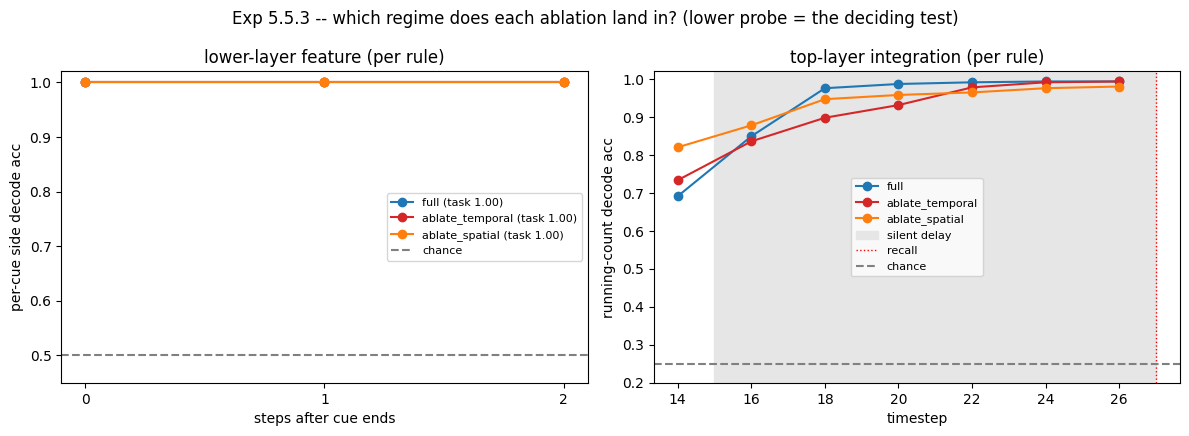

Saved exp5_5_ablation_probes.


In [18]:
# ── 5.5.3  Ablation-aware probes: does the lower layer LEARN under each rule? ──
# Closes the gap in 5.4.2 (which probed only full-vs-random): train a compact net UNDER
# EACH RULE (deep-e-prop grads + Adam), then linearly probe its lower + top layers. Reads
# off which regime each ablation lands in -- a real feature extractor vs a reservoir --
# which task accuracy cannot (all rules reach ~99%). SMOKE locally, then raise for Colab.
assert "e54_lower_probe" in globals(), "Run the 5.4 setup cell first."
from learning_rules.deep_eprop import compute_deep_eprop_gradients, xent_error

E55_SMOKE = False   # <-- set False for full run on Colab (~3000 steps)
E55_STEPS = 800 if E55_SMOKE else 3000        # Adam steps per rule (near-converged at 800)
E55_SEED  = 0                                 # single seed; raise / loop for tighter bands
E55_RULES = {"full":            dict(mode="full"),
             "ablate_temporal": dict(mode="ablate_temporal"),
             "ablate_spatial":  dict(mode="ablate_spatial")}

def e55_train_rule(seed, **grad_kw):
    m = e54_new_model(seed)
    opt = torch.optim.Adam(m.parameters(), lr=E54_LR)
    for st in range(E55_STEPS):
        inp, tgt, msk = e54_batch(E54_BATCH, 800_000 + seed * 1_000_000 + st)
        g = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, **grad_kw)
        opt.zero_grad()
        for name, p in m.named_parameters():
            p.grad = g.get(name, torch.zeros_like(p))
        torch.nn.utils.clip_grad_norm_(m.parameters(), E54_GRAD_CLIP)
        opt.step()
    return m

print(f"5.5.3 ablation probes | steps/rule={E55_STEPS} SMOKE={E55_SMOKE} ...")
e55 = {}
for rule, kw in E55_RULES.items():
    t0 = time.time(); m = e55_train_rule(E55_SEED, **kw)
    low = e54_lower_probe(m); top, _ = e54_top_probe(m); acc = e54_eval(m)
    e55[rule] = dict(acc=acc, lower=low, top=top)
    print(f"  {rule:16s} task-acc={acc:.3f}  lower(off{E54_LOWER_OFFSETS[0]}->off{E54_LOWER_OFFSETS[-1]}) "
          f"{low[0][1]:.2f}->{low[-1][1]:.2f}  top@recall {top[-1][1]:.2f}  [{time.time()-t0:.0f}s]")
json.dump(e55, open("results/exp5_5_ablation_probes.json", "w"), indent=1)

# ── figure: lower-layer feature persistence + top-layer count, per rule ──────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
offs = E54_LOWER_OFFSETS
for rule, c in [("full", "C0"), ("ablate_temporal", "C3"), ("ablate_spatial", "C1")]:
    axL.plot(offs, [a for _, a, _ in e55[rule]["lower"]], "-o", color=c,
             label=f"{rule} (task {e55[rule]['acc']:.2f})")
    axR.plot([t for t, _, _ in e55[rule]["top"]], [a for _, a, _ in e55[rule]["top"]],
             "-o", color=c, label=rule)
axL.axhline(0.5, color="gray", ls="--", label="chance"); axL.set_xticks(offs)
axL.set_xlabel("steps after cue ends"); axL.set_ylabel("per-cue side decode acc")
axL.set_ylim(0.45, 1.02); axL.set_title("lower-layer feature (per rule)"); axL.legend(fontsize=8)
axR.axvspan(CUE_WINDOW, T_RECALL, color="0.9", label="silent delay")
axR.axvline(T_RECALL, color="r", ls=":", lw=1, label="recall")
axR.axhline(1.0 / (E54_NCUES + 1), color="gray", ls="--", label="chance")
axR.set_xlabel("timestep"); axR.set_ylabel("running-count decode acc")
axR.set_ylim(0.2, 1.02); axR.set_title("top-layer integration (per rule)"); axR.legend(fontsize=8)
fig.suptitle("Exp 5.5.3 -- which regime does each ablation land in? (lower probe = the deciding test)")
fig.tight_layout(); e54_save(fig, "exp5_5_ablation_probes"); plt.show()
print("Saved exp5_5_ablation_probes.")
